Imports and Loads Data 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

train = pd.read_csv('../datasets/train.csv')
test = pd.read_csv('../datasets/test.csv')

Split Features and Targets 

In [10]:
X_train = train.drop(columns = ['Heating Load', 'Cooling Load'])
Y_train = train[['Heating Load', 'Cooling Load']]

X_test = test.drop(columns = ['Heating Load', 'Cooling Load'])
Y_test = test[['Heating Load', 'Cooling Load']]



Linear Regression Model 

In [11]:
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print(f'Linear Regression - MSE: {mse:.2f}, R2: {r2:.2f}')

Linear Regression - MSE: 9.31, R2: 0.90


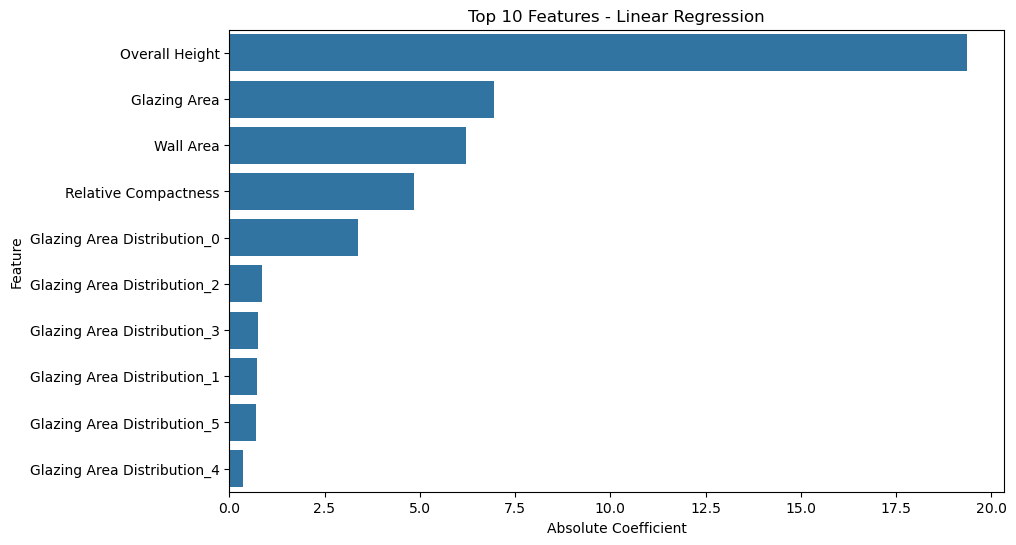

In [12]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': abs(model.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize = (10, 6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature')
plt.title('Top 10 Features - Linear Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.show()

Ridge Regression

Ridge — Train Score: 0.89, Test Score: 0.89


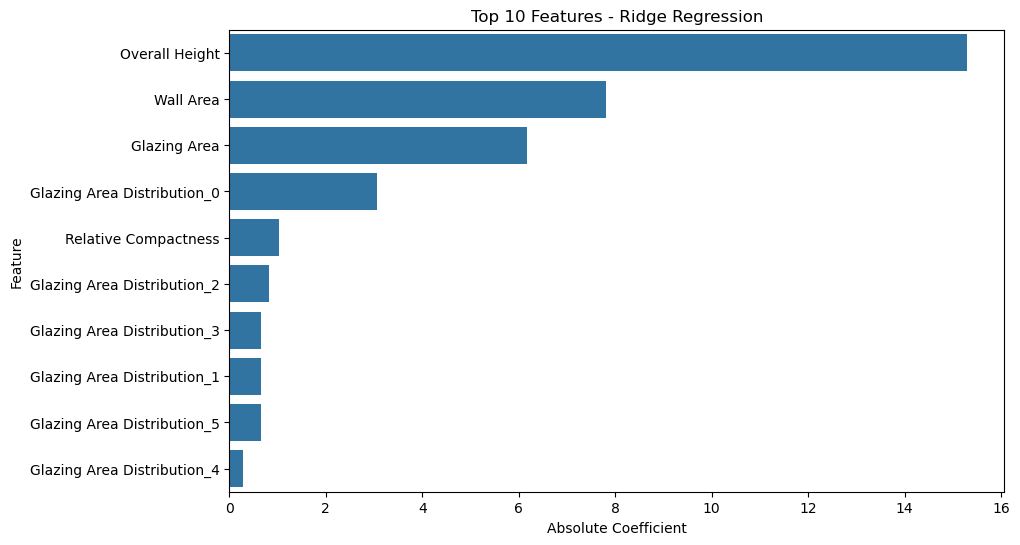

In [15]:
ridge = Ridge(alpha=10)
ridge.fit(X_train, Y_train)

train_score = ridge.score(X_train, Y_train)
test_score = ridge.score(X_test, Y_test)
print(f'Ridge — Train Score: {train_score:.2f}, Test Score: {test_score:.2f}')

ridge_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': abs(ridge.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=ridge_coef_df.head(10), x='Coefficient', y='Feature')
plt.title('Top 10 Features - Ridge Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.show()

Lasso Regression

Lasso — Train Score: 0.90, Test Score: 0.90


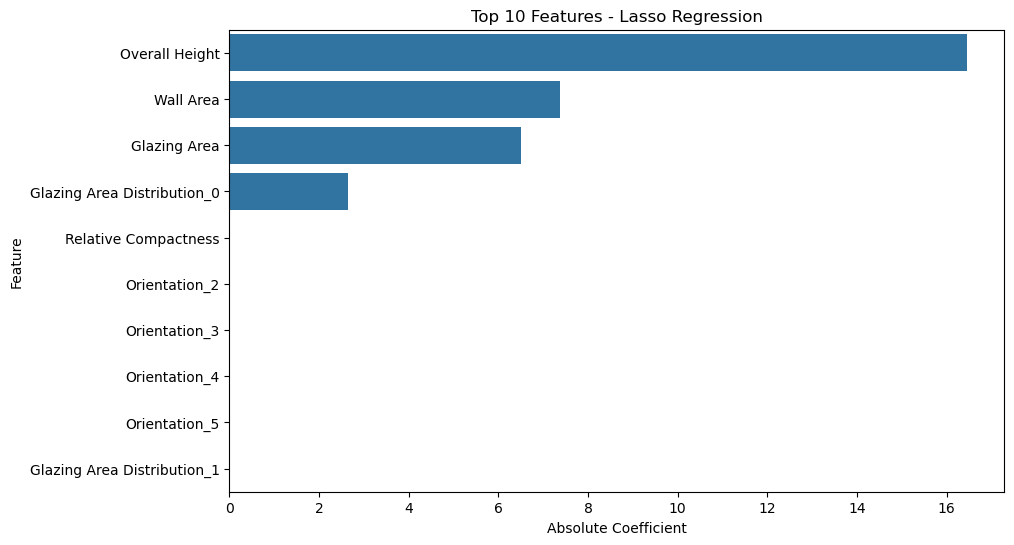

In [16]:
# Lasso Regression Model
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, Y_train)

train_score = lasso.score(X_train, Y_train)
test_score = lasso.score(X_test, Y_test)
print(f'Lasso — Train Score: {train_score:.2f}, Test Score: {test_score:.2f}')

# Feature importance chart
lasso_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': abs(lasso.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lasso_coef_df.head(10), x='Coefficient', y='Feature')
plt.title('Top 10 Features - Lasso Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.show()

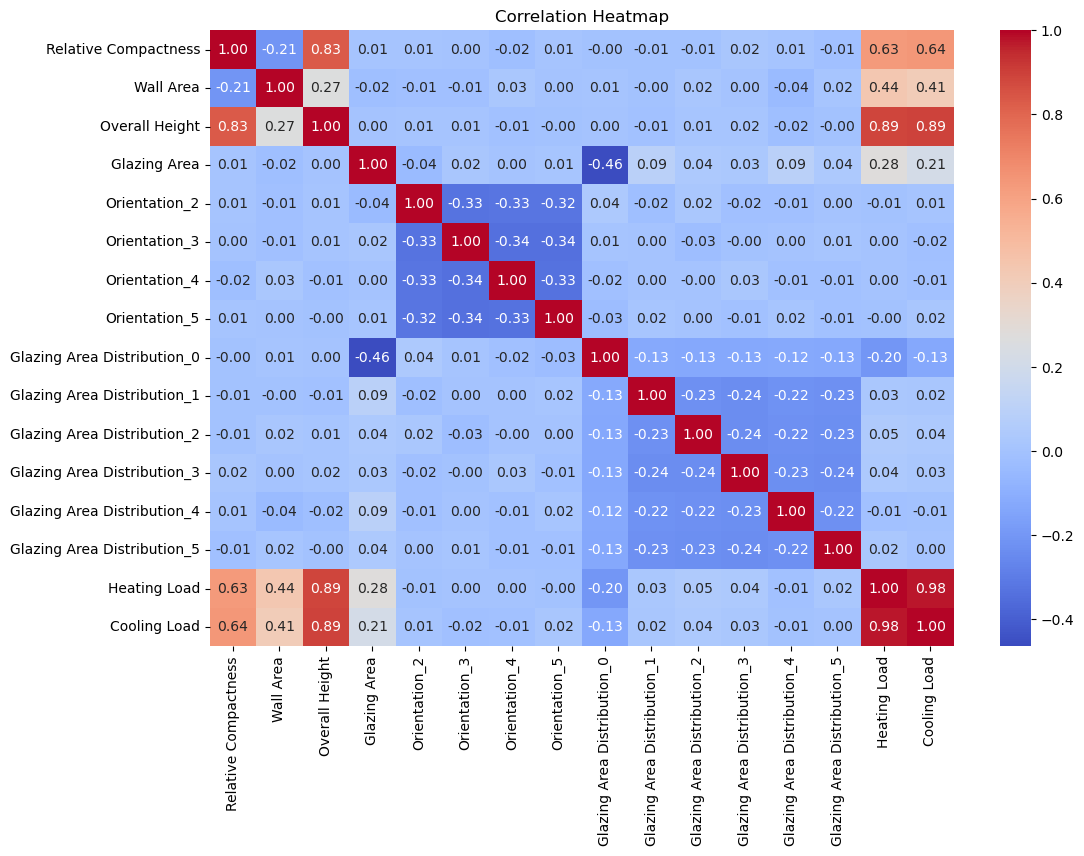

In [17]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = pd.concat([X_train, Y_train], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Overall Analysis

Three regression models were applied to predict building energy loads. The Linear Regression baseline achieved an MSE of 9.31 and R2 of 0.90, explaining 90% of the variance. Ridge Regression helped address multicollinearity by balancing the feature coefficients, while Lasso Regression zeroed out Orientation and most Glazing Area Distribution features, confirming they have little predictive value. Across all three models, Overall Height, Glazing Area, and Wall Area consistently emerged as the strongest predictors of building energy loads.